In [15]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal



In [16]:
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)

  L.append(a + b)
len(L)

10000

In [17]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

In [18]:
np.cumsum(s)

,count
2,0.0278
3,0.0815
4,0.1688
5,0.2785
6,0.4176
7,0.5846
8,0.7218
9,0.8349
10,0.9175
11,0.9730


<Axes: >

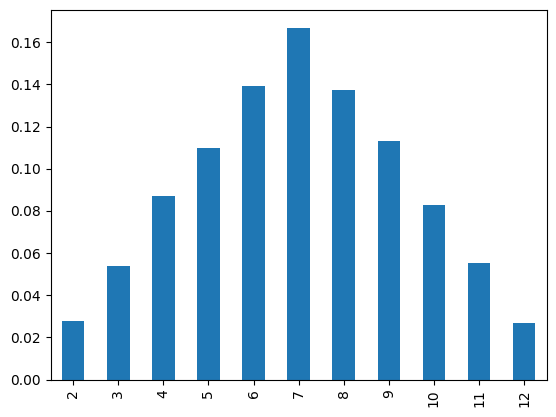

In [19]:
s.plot(kind = 'bar')

<Axes: >

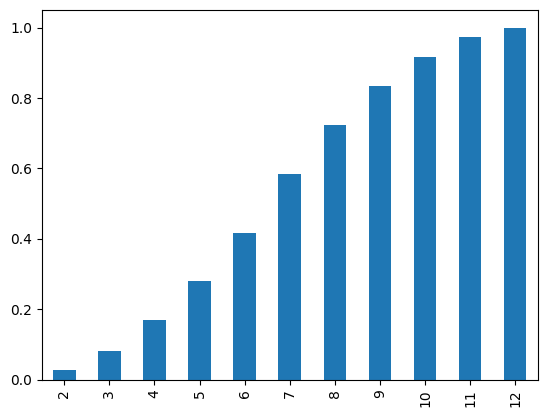

In [20]:
np.cumsum(s).plot(kind='bar')

Parametric Densiry Estimation

In [21]:
sample = normal(loc = 50, scale = 5, size = 1000)

In [22]:
sample

array([46.01105199, 50.51499831, 51.46194591, 50.8178006 , 44.92816392,
       51.54373457, 48.67863571, 52.33952262, 49.96524024, 51.20075097,
       47.91864215, 48.34286748, 52.74088503, 52.10054691, 49.63305604,
       41.84068902, 51.74367716, 58.40610215, 61.74811564, 50.87365863,
       48.41660088, 48.98241954, 44.87613109, 50.02968945, 51.45108629,
       54.26250414, 45.274805  , 47.62755193, 61.18501138, 41.6898865 ,
       52.93849121, 47.99030781, 51.17640274, 39.04747594, 47.2484329 ,
       47.64398311, 51.91603145, 49.93303631, 48.71276124, 46.47165536,
       45.685748  , 59.59390638, 51.09759152, 41.20058722, 51.60339979,
       53.04222367, 57.14515019, 53.45150355, 49.7836038 , 49.4501923 ,
       49.8656477 , 49.17155201, 56.72553436, 55.663316  , 42.57011912,
       52.1021646 , 54.236218  , 54.3935757 , 52.43073063, 58.76994865,
       46.43376038, 53.83121732, 49.84511966, 56.00193291, 48.97125469,
       49.37232843, 55.95264607, 60.73702079, 51.52435482, 45.69

In [3]:
sample.mean()

np.float64(50.04678518636388)

(array([  9.,  16.,  65., 135., 220., 236., 177.,  87.,  38.,  17.]),
 array([34.3067628 , 37.25450579, 40.20224877, 43.14999175, 46.09773474,
        49.04547772, 51.9932207 , 54.94096369, 57.88870667, 60.83644966,
        63.78419264]),
 <BarContainer object of 10 artists>)

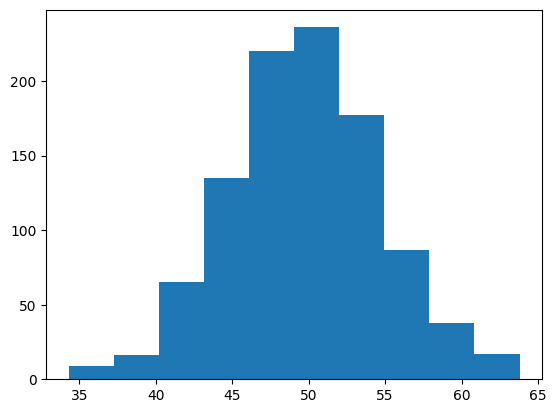

In [23]:
#plotting a histogram to see the data distribution
plt.hist(sample,bins = 10)

In [5]:
sample_mean = sample.mean()
sample_std = sample.std()

In [6]:
#fit the distribution with the above parameters
from scipy.stats import norm

dist = norm(sample_mean, sample_std)

In [25]:
sample.min()
sample.max()

np.float64(63.78419264008011)

In [7]:
#providing x
values = np.linspace(sample.min(), sample.max(),100)

In [8]:
probabilities = [dist.pdf(value) for value in values]

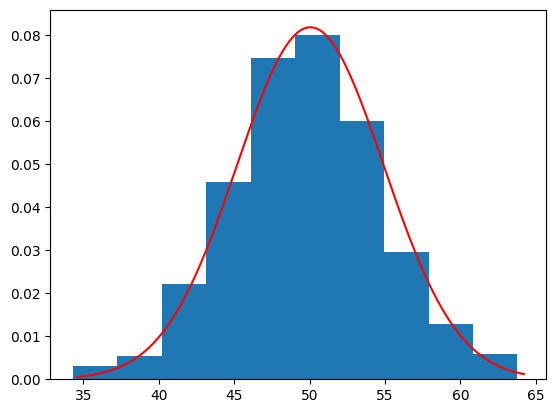

In [28]:
plt.hist(sample, bins = 10 ,density= True)
plt.plot(values, probabilities, 'r') # x vs probabilities

/tmp/ipykernel_4718/1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

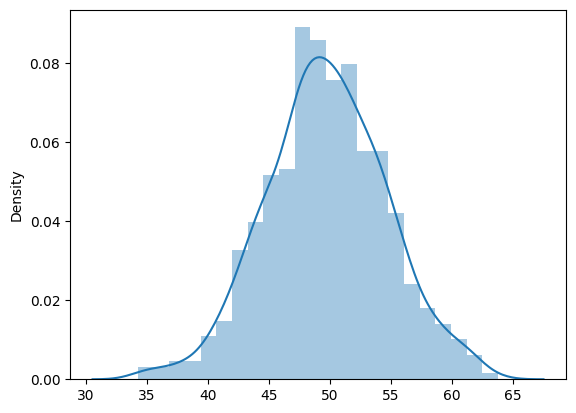

In [34]:
import seaborn as sns
sns.distplot(sample)

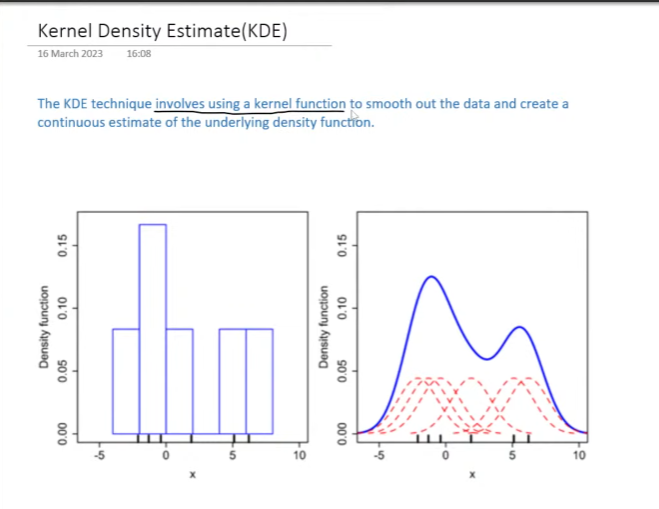

KDE

In [35]:
#samples
sample1 = normal(loc = 20, scale = 5, size = 300)
sample2 = normal(loc = 40, scale = 5, size = 700)
sample = np.hstack((sample1,sample2))

In [36]:
sample

array([24.56115028, 23.22988717, 15.84241241, 15.4872933 , 10.66669431,
       24.72761411, 17.92206917, 21.19735277, 14.1325345 , 23.10154625,
        8.82904939, 26.072168  , 19.01810971,  9.78528819, 19.16475207,
       21.74676277, 33.48545933, 26.26182003, 17.38102418, 28.11656964,
       14.77306075,  9.36821123, 25.75135828, 22.09795242, 19.79606975,
       15.48941459, 23.13042402, 21.39283406, 21.29603869, 19.76080539,
       13.25897569, 17.98941777, 25.26654428, 22.63420399, 17.47698906,
       19.0317483 , 12.43502006, 21.96297606, 26.98297104, 24.34571255,
       11.78765484, 21.69116526, 14.54496518, 26.00287288, 20.0233348 ,
       19.75296824, 19.00100853, 24.58749141, 14.21028619, 14.93264   ,
       12.59031724, 27.58690206, 21.71392053, 22.38324478, 15.06133687,
       21.97314412, 16.44142776, 30.26963771, 17.49317227,  9.20616246,
       25.85267647, 18.44368878, 20.1456909 , 25.47228599, 11.89697196,
       15.01578064, 21.65579582, 20.5348488 , 22.61407901, 21.39

(array([ 2.,  0.,  1.,  3.,  4.,  4.,  4., 12., 15., 21., 16., 20., 13.,
        21., 19., 23., 24., 20., 23., 27., 13., 11.,  8.,  8., 22., 13.,
        28., 34., 46., 49., 55., 52., 65., 55., 47., 47., 42., 34., 28.,
        19., 21., 19.,  3.,  2.,  2.,  3.,  1.,  0.,  0.,  1.]),
 array([ 5.10344814,  6.16965331,  7.23585847,  8.30206363,  9.3682688 ,
        10.43447396, 11.50067912, 12.56688429, 13.63308945, 14.69929461,
        15.76549978, 16.83170494, 17.8979101 , 18.96411527, 20.03032043,
        21.09652559, 22.16273076, 23.22893592, 24.29514108, 25.36134624,
        26.42755141, 27.49375657, 28.55996173, 29.6261669 , 30.69237206,
        31.75857722, 32.82478239, 33.89098755, 34.95719271, 36.02339788,
        37.08960304, 38.1558082 , 39.22201337, 40.28821853, 41.35442369,
        42.42062886, 43.48683402, 44.55303918, 45.61924435, 46.68544951,
        47.75165467, 48.81785984, 49.884065  , 50.95027016, 52.01647533,
        53.08268049, 54.14888565, 55.21509082, 56.28129598,

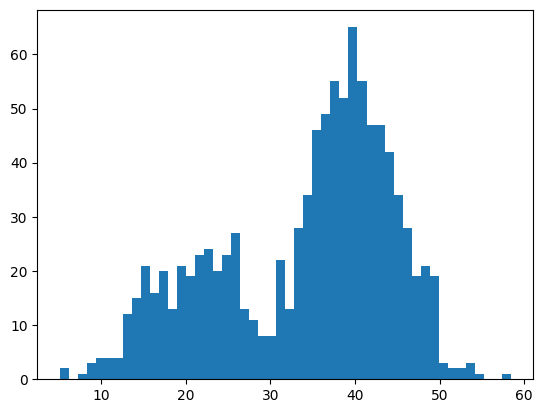

In [37]:
plt.hist(sample,bins=50)

In [62]:
from sklearn.neighbors import KernelDensity
model = KernelDensity(bandwidth = 3, kernel = 'gaussian')
#convert data to 2D array
model.fit(sample.reshape(len(sample),1))



KernelDensity(bandwidth=3)

In [63]:
values = np.linspace(sample.min(), sample.max(),100)
values = values.reshape(len(values),1)

In [64]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

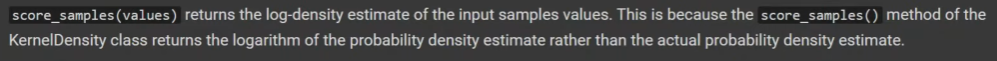

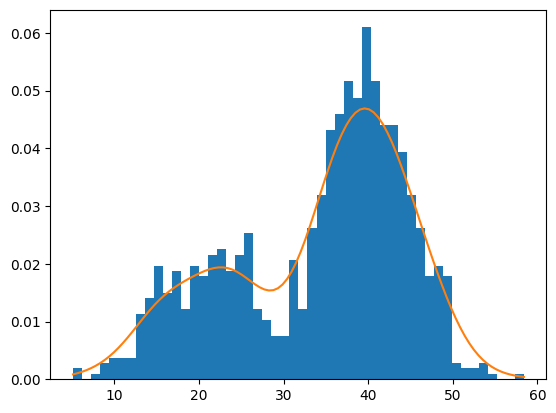

In [65]:
plt.hist(sample, bins = 50 ,density= True)
plt.plot(values, probabilities)

<Axes: ylabel='Density'>

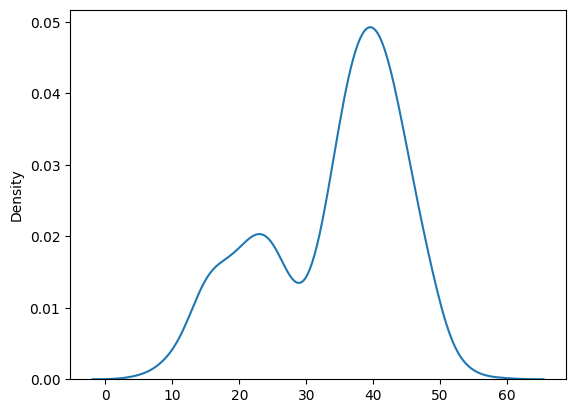

In [72]:
sample_sns = sample.reshape(1000)
sns.kdeplot(sample_sns, bw_adjust = 0.9)